In [1]:
# checking all works with no albedo correction


# 02-Jul-2026 IGH

In [2]:
from astropy.time import Time, TimeDelta
from astropy import units as u
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# Using sunkit-spex 0.1.dev214+g7f350be51
from sunkit_spex.legacy import thermal
from sunkit_spex.extern.rhessi import RhessiLoader
from sunkit_spex.legacy.fitting.fitter import Fitter
from sunkit_spex.legacy.fitting.albedo import get_albedo_matrix

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning) 
plt.rcParams['font.size'] = 14

In [3]:
fdir = "fits/"
fspec="hsi_spectrum_20021005_0938_1114_3_250keV_alld.fits"
fsrm="hsi_srm_20021005_1040_1056_3_250keV_alld.fits"

ftims=Time(['2002-10-05T10:41:20.000','2002-10-05T10:42:24.000'],format='isot')
btims=Time(['2002-10-05T10:38:32.000','2002-10-05T10:40:32.000'],format='isot')

In [4]:
rhess_spec = RhessiLoader(spectrum_fn=fdir+fspec, srm_fn=fdir+fsrm)
rhess_spec.update_background_times(btims[0],btims[1])
rhess_spec.update_event_times(ftims[0],ftims[1])

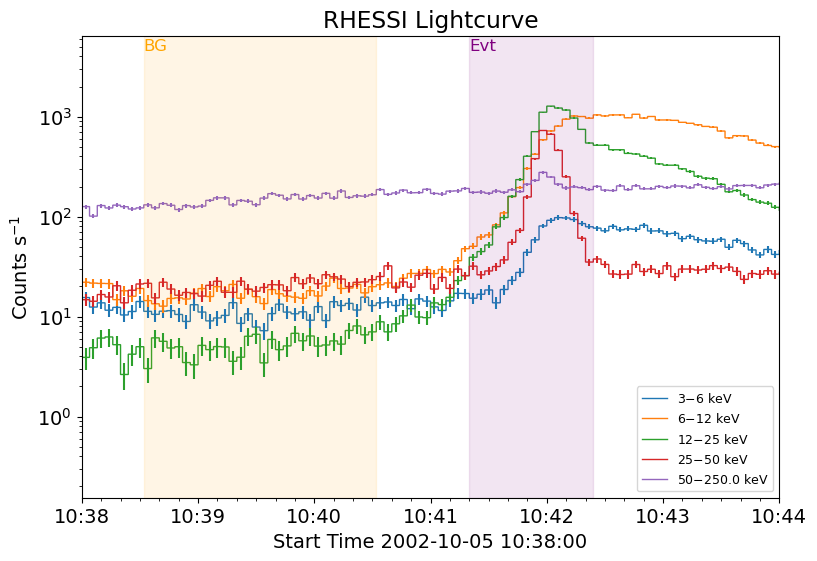

In [5]:
tr=Time(['2002-10-05T10:38:00.000','2002-10-05T10:44:00.000'],format='isot')

plt.figure(figsize=(9,6))
ax=rhess_spec.lightcurve(energy_ranges=[[3,6], [6,12], [12,25], [25,50],[50,1000]])
ax.set_xlim(tr[0].datetime,tr[1].datetime)
ax.set_xlabel("Start Time "+tr[0].iso[:19])
ax.xaxis.set_minor_locator(matplotlib.dates.SecondLocator(interval=10))
ax.xaxis.set_major_locator(matplotlib.dates.MinuteLocator(interval=1))
ax.xaxis.set_major_formatter(matplotlib.dates.DateFormatter('%H:%M'))
plt.show()

In [6]:
fitter = Fitter(rhess_spec)
# fitter.albedo_corr=True
# # Flare at 382.7, -405.2 -> spex source angle 35.4919
# fitter.albedo_angle=35.4919 * u.deg

fitter.model = "(f_vth+thick_fn)"
fitter.loglikelihood = "cstat"

In [7]:
# As A1 only fit > 6keV
fitter.energy_fitting_range = [6,15]
fitter.params["T1_spectrum1"] = {"Value":22, "Bounds":(10, 30)}
fitter.params["EM1_spectrum1"] = {"Value":10, "Bounds":(1e-1, 1e3)}
fitter.params["total_eflux1_spectrum1"] = {"Status":"fix", "Value":0.1, "Bounds":(1e-3, 1e2)}
fitter.params["index1_spectrum1"] = {"Status":"fix", "Value":6, "Bounds":(2, 12)}
fitter.params["e_c1_spectrum1"] = {"Status":"fix", "Value":20, "Bounds":(5, 30)}
spec_fit = fitter.fit()

# Then non-thermal fit higher energy
fitter.energy_fitting_range = [15,45]
fitter.params["T1_spectrum1"] = "fix"
fitter.params["EM1_spectrum1"] = "fix"
fitter.params["total_eflux1_spectrum1"] = "free"
fitter.params["index1_spectrum1"] = "free"
fitter.params["e_c1_spectrum1"] = "free"
spec_fit = fitter.fit()

# The do the full range
fitter.energy_fitting_range = [6,45]
fitter.params["T1_spectrum1"] = "free"
fitter.params["EM1_spectrum1"] = "free"
fitter.params["total_eflux1_spectrum1"] = "free"
fitter.params["index1_spectrum1"] = "free"
fitter.params["e_c1_spectrum1"] = "free"
spec_fit = fitter.fit()

/Users/iain/github/sunkit-spex/sunkit_spex/legacy/thermal.py:763: UserWarning: Some input energy values outside valid range of 1.0002920302956426--200.15819869050395 keV. Flux will be zero outside this range.
  warnings.warn(message)


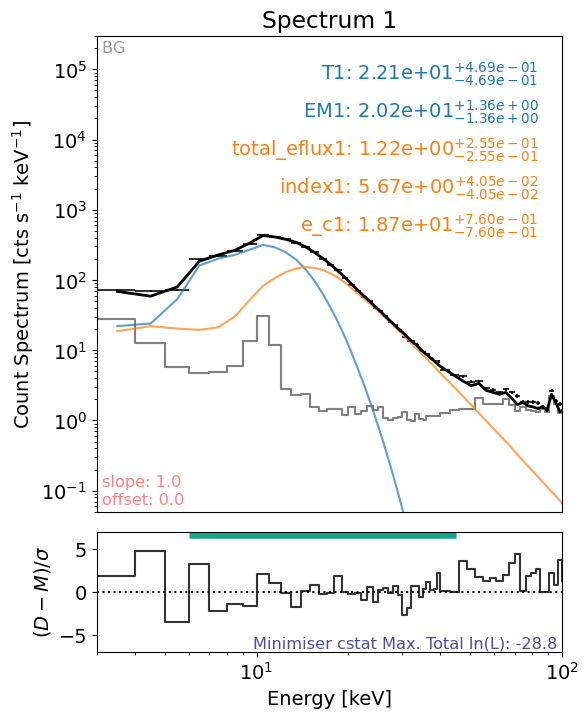

In [8]:
xlims, ylims = [3,100], [5e-2,3e5]

plt.figure(figsize=(6,8))
axes, res_axes = fitter.plot()
for a in axes:
    a.set_xlim(xlims)
    a.set_ylim(ylims)
    a.set_xscale("log")
plt.show()

In [9]:
# Let's extract all the info, for testing and to make a nicer plot
# Get all the fit parameters
tmk=fitter.params["T1_spectrum1"]['Value']
tmk_ci=[tmk-fitter.params["T1_spectrum1"]['Error'][0],tmk+fitter.params["T1_spectrum1"]['Error'][1]]
em=fitter.params["EM1_spectrum1"]['Value']*1e46
em_ci=[em-fitter.params["EM1_spectrum1"]['Error'][0]*1e46,\
    em+fitter.params["EM1_spectrum1"]['Error'][1]*1e46]
ntot=fitter.params["total_eflux1_spectrum1"]["Value"]*1e35
ntot_err=[fitter.params["total_eflux1_spectrum1"]["Error"][0]*1e35,\
          fitter.params["total_eflux1_spectrum1"]["Error"][1]*1e35]
ind=fitter.params["index1_spectrum1"]["Value"]
ind_err=[fitter.params["index1_spectrum1"]["Error"][0],fitter.params["index1_spectrum1"]["Error"][1]]
ec=fitter.params["e_c1_spectrum1"]["Value"]
ec_err=[fitter.params["e_c1_spectrum1"]["Error"][0],fitter.params["e_c1_spectrum1"]["Error"][1]]

# Make the labels look nice for the plot
tmks=f'{tmk:4.2f}'
tmkups=f'{tmk_ci[1]-tmk:4.2f}'
tmkdns=f'{tmk-tmk_ci[0]:4.2f}'
ems=f'{em*1e-46:4.2f}'
emups=f'{(em_ci[1]-em)*1e-46:4.2f}'
emdns=f'{(em-em_ci[0])*1e-46:4.2f}'
nts=f'{ntot*1e-34:4.2f}'
ntups=f'{ntot_err[1]*1e-34:4.2f}'
ntdns=f'{ntot_err[0]*1e-34:4.2f}'
inds=f'{ind:4.2f}'
indups=f'{ind_err[1]:4.2f}'
inddns=f'{ind_err[0]:4.2f}'
ecs=f'{ec:4.2f}'
ecups=f'{ec_err[1]:4.2f}'
ecdns=f'{ec_err[0]:4.2f}'
# Non-thermal power
nnpow=1.6e-9*ntot*ec*(ind-1)/(ind-2)
nnpows=f'{nnpow*1e-26:4.2f}'

lnl=fitter._get_max_fit_stat()
lnls=f'{lnl:.2f}'

# Get the data and fits to replot
engs=fitter.plotting_info['spectrum1']['count_channels']
edels=fitter.plotting_info['spectrum1']['count_channel_error']
rat=fitter.plotting_info['spectrum1']['count_rates']
erat=fitter.plotting_info['spectrum1']['count_rate_errors']
backrat=rhess_spec._loaded_spec_data["extras"]["background_rate"]
backraterr=rhess_spec._loaded_spec_data["extras"]["background_rate_error"]
# Calc total error in back sub data
rbserr=np.sqrt(erat**2+backraterr**2)
resid=fitter.plotting_info['spectrum1']['residuals'][::2]
fmd=fitter.plotting_info['spectrum1']['count_rate_model']
sfmd=fitter.plotting_info['spectrum1']['submodels']
fiter=fitter.plotting_info['spectrum1']['fitting_range']
# Sort out the energy binning steps for plotting
stepe = np.asarray([engs[i] - edels[i] for i in range(len(engs))] + [engs[-1] + edels[-1]])
ns=len(stepe)

# Get the albedo - new code only
# fal=fitter.plotting_info['spectrum1']['albedo_excess_count'] 
# Calculate the total model + albedo
fmd=sfmd[0]+sfmd[1] 

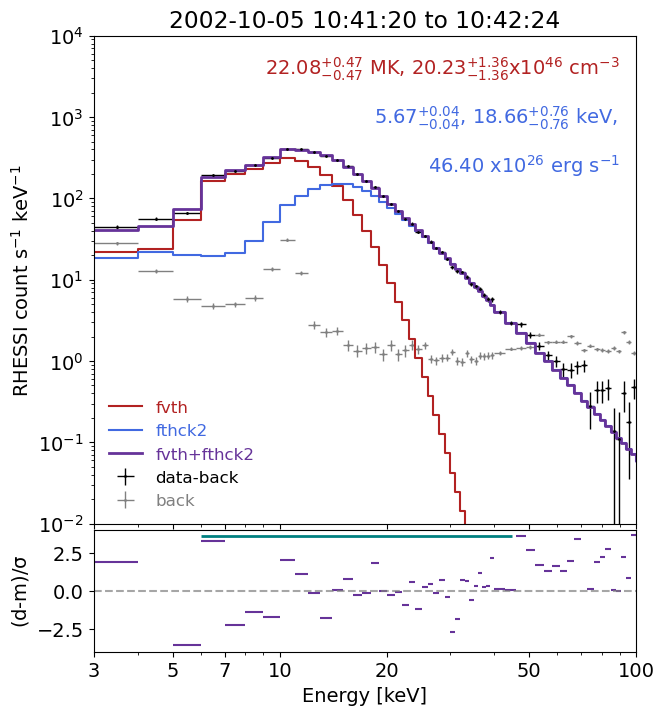

In [10]:
plt.rcParams.update({'mathtext.default': 'regular'})
yrlim=[-4,4]
xlim, ylim = [3,100], [1e-2,1e4]
gs_kw = dict(height_ratios=[4,1], hspace=0.02, wspace=0.05)
fig, axs = plt.subplots(ncols=1, nrows=2, constrained_layout=False, gridspec_kw=gs_kw, figsize=(7,8))

axs[0].errorbar(engs, rat-backrat, xerr=edels, yerr=rbserr, fmt='.', color='k', lw=1., ms=2, label='data-back')
axs[0].errorbar(engs, backrat, xerr=edels, yerr=backraterr, fmt='.', color='grey', lw=1., ms=2, label='back')

# axs[0].step(stepe[0:ns-1], fal[0:ns-1], where='post', color='goldenrod', label='albedo')
axs[0].step(stepe[0:ns-1], sfmd[0][0:ns-1], where='post', color='firebrick', label='fvth')
axs[0].step(stepe[0:ns-1], sfmd[1][0:ns-1], where='post', color='royalblue', label='fthck2')
axs[0].step(stepe[0:ns-1], fmd[0:ns-1], where='post', color='rebeccapurple', lw=2, label='fvth+fthck2')

axs[0].legend(loc=3, labelcolor='linecolor', frameon=False, prop={'size': 12})
axs[0].text(0.97,0.92,tmks+'$^{+'+tmkups+'}_{-'+tmkdns+'}$ MK, '+ems+'$^{+'+emups+'}_{-'+emdns+r'}$x10$^{46}$ cm$\mathit{^{-3}}$', color='firebrick', ha='right', transform=axs[0].transAxes)
axs[0].text(0.97,0.82,inds+'$^{+'+indups+'}_{-'+inddns+'}$, '+ecs+'$^{+'+ecups+'}_{-'+ecdns+'}$ keV, ', color='royalblue', ha='right', transform=axs[0].transAxes)
axs[0].text(0.97,0.72,nnpows+r' x10$^{26}$ erg s$\mathit{^{-1}}$', color='royalblue', ha='right', transform=axs[0].transAxes)
# axs[0].text(0.97,0.65,r'max $\ln{\mathcal{L}}$ '+lnls, color='rebeccapurple', transform=axs[0].transAxes, ha='right', fontsize='16')
axs[1].hlines(resid, stepe[0:-1], stepe[1:], color='rebeccapurple', lw=1.5)

axs[0].set_ylabel(r'RHESSI count s$\mathit{^{-1}}$ keV$\mathit{^{-1}}$')
axs[0].set_xlabel(' ')
axs[0].set_yscale('log')
axs[0].set_ylim(ylim)
axs[0].set_title(ftims.iso[0][:-4]+' to '+ftims.iso[1][11:-4])

axs[1].set_ylabel(r'(d-m)/$\sigma$')
axs[1].set_ylim(yrlim)
axs[1].set_xlabel('Energy [keV]')
axs[1].hlines(0.0, xlims[0], xlims[1], color='grey', linestyle='--', alpha=0.7)
axs[1].hlines(yrlim[1]*0.9, fiter[0], fiter[1], color='teal', lw=2)

for aaxx in axs:
    aaxx.set_xlim(xlim)
    aaxx.set_xscale('log')
    aaxx.set_xticks([3,5,7,10,20,50,100])
    aaxx.get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
axs[0].set_xticklabels([])
plt.show()

In [11]:
import sunpy
import sunkit_spex
print("SunPy:", sunpy.__version__)
print("sunkit_spex:", sunkit_spex.__version__)
# sunpy.system_info()
# 
# All these setups produce the same results
# 
# Macbook pro setup
# SunPy: 7.1.2
# sunkit_spex: 0.1.dev253+gb7b054638
# 
# Macbook air setup
# SunPy: 7.1.2
# sunkit_spex: 0.1.dev214+g7f350be51
# 
# trifid setup
# SunPy: 8.0.0
# sunkit_spex: 0.5.1.dev4+g32c58fcc2

SunPy: 8.0.0
sunkit_spex: 0.5.1.dev8+g43d3b09e9.d20260715
